In [0]:
#Main Libraries
import pandas as pd
import numpy as np

# Data Processing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Data Loading:

In [0]:
df = spark.table("workspace.default.retail_sales_dataset").toPandas()
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### EDA:

In [0]:
df.shape

(1000, 9)

Data contains 1000 rows and 9 columns

In [0]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

The code above gives the column names

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


Observation above is that there are no null values, there's 8 columns and 1000 rows. Data type is only integers and objects

In [0]:
#In case there were nulls we run the following to consolidate:

df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

<Axes: title={'center': 'Null Value Visual'}>

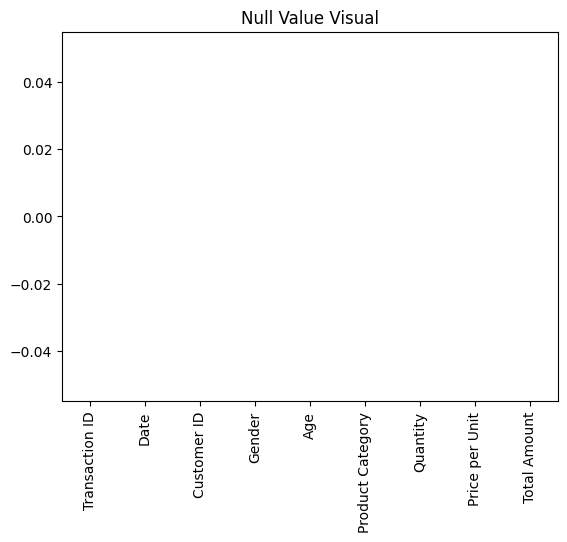

In [0]:
#How to visualize the nulls:

df.isnull().sum().plot(kind = 'bar', title = "Null Value Visual")

In [0]:
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [0]:
df.tail(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
990,991,2023-12-26,CUST991,Female,34,Clothing,2,50,100
991,992,2023-08-21,CUST992,Female,57,Electronics,2,30,60
992,993,2023-02-06,CUST993,Female,48,Electronics,3,50,150
993,994,2023-12-18,CUST994,Female,51,Beauty,2,500,1000
994,995,2023-04-30,CUST995,Female,41,Clothing,1,30,30
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


From the observation above we can drop the Transaction id & Customer id

In [0]:
df.drop(["Transaction ID", "Customer ID"], axis = 1)
#df.head(3)

,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,2023-11-24,Male,34,Beauty,3,50,150
1,2023-02-27,Female,26,Clothing,2,500,1000
2,2023-01-13,Male,50,Electronics,1,30,30
3,2023-05-21,Male,37,Clothing,1,500,500
4,2023-05-06,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...
995,2023-05-16,Male,62,Clothing,1,50,50
996,2023-11-17,Male,52,Beauty,3,30,90
997,2023-10-29,Female,23,Beauty,4,25,100
998,2023-12-05,Female,36,Electronics,3,50,150


In [0]:
df.drop(columns=['Transaction ID', 'Customer ID'], inplace=True)

In [0]:
df.head(1)

,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,2023-11-24,Male,34,Beauty,3,50,150


In [0]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [0]:
df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

In [0]:
fig = px.bar(
x=df["Gender"].value_counts().index,
y=df["Gender"].value_counts().values,
labels={"x": "Gender", "y": "Count"},
title="Gender Distribution"
)
fig.show()

Observation above shows that there is not much variance on the gender for Males and Females

In [0]:
gender_counts = df["Product Category"].value_counts().reset_index()
gender_counts.columns = ["Product Category", "Count"]
fig = px.bar(
gender_counts,
x="Product Category",
y="Count",
color="Product Category",
text="Count",
title="Product Category Distribution"
)
fig.update_layout(
xaxis_title="Product Category",
yaxis_title="Count",
showlegend=False
)

fig.show()

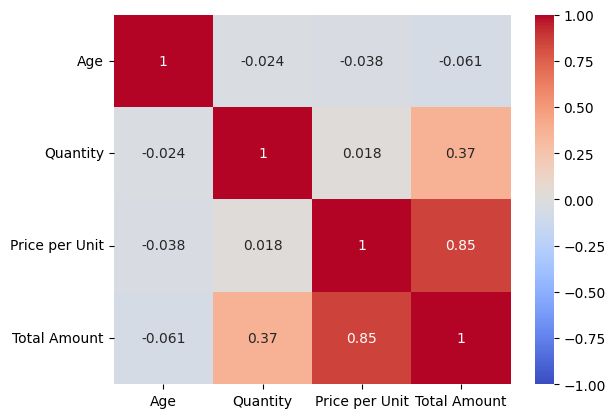

In [0]:
matrix = df.corr(numeric_only=True)

# Plot heatmap with values labeled inside the cells
sns.heatmap(matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [0]:
df.head(1)

,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,2023-11-24,Male,34,Beauty,3,50,150


### Encoding:

In [0]:
# 2. Initialize the LabelEncoder
le = LabelEncoder()

# 3. Fit and transform the categorical data
df['Gender_encoded'] = le.fit_transform(df['Gender'])
df['Product Category_encoded']=le.fit_transform(df['Product Category'])

print(df)
print("\nCategory Mapping:", le.classes_)

           Date  Gender  ...  Gender_encoded Product Category_encoded
0    2023-11-24    Male  ...               1                        0
1    2023-02-27  Female  ...               0                        1
2    2023-01-13    Male  ...               1                        2
3    2023-05-21    Male  ...               1                        1
4    2023-05-06    Male  ...               1                        0
..          ...     ...  ...             ...                      ...
995  2023-05-16    Male  ...               1                        1
996  2023-11-17    Male  ...               1                        0
997  2023-10-29  Female  ...               0                        0
998  2023-12-05  Female  ...               0                        2
999  2023-04-12    Male  ...               1                        2

[1000 rows x 9 columns]

Category Mapping: ['Beauty' 'Clothing' 'Electronics']


In [0]:
df.head(2)

,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Gender_encoded,Product Category_encoded
0,2023-11-24,Male,34,Beauty,3,50,150,1,0
1,2023-02-27,Female,26,Clothing,2,500,1000,0,1


In [0]:
df.columns

Index(['Date', 'Gender', 'Age', 'Product Category', 'Quantity',
       'Price per Unit', 'Total Amount', 'Gender_encoded',
       'Product Category_encoded'],
      dtype='object')

In [0]:
cols = ["Age", "Quantity", "Price per Unit", "Total Amount",
        "Gender_encoded", "Product Category_encoded"]

dff = df[cols]        # This is now a DataFrame

In [0]:
dff

,Age,Quantity,Price per Unit,Total Amount,Gender_encoded,Product Category_encoded
0,34,3,50,150,1,0
1,26,2,500,1000,0,1
2,50,1,30,30,1,2
3,37,1,500,500,1,1
4,30,2,50,100,1,0
...,...,...,...,...,...,...
995,62,1,50,50,1,1
996,52,3,30,90,1,0
997,23,4,25,100,0,0
998,36,3,50,150,0,2


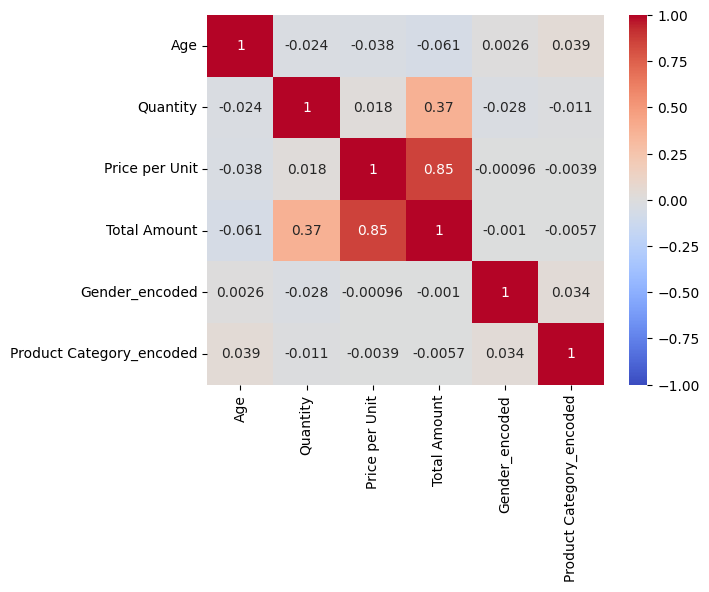

In [0]:
matrix = dff.corr()

sns.heatmap(matrix,
            annot=True,
            cmap="coolwarm",
            vmin=-1,
            vmax=1)

plt.show()